# CS3807 Deep Learning Laboratory - Experiment 6
## End-to-End Study of RNN, LSTM and GRU for Sequence Learning and Video Understanding

This notebook implements everything in the lab manual:
1. UCI HAR preprocessing into `(N, 128, 9)` sequences
2. Temporal visualization
3. BPTT numerical exercise (manual vs program)
4. Vanilla RNN, LSTM, GRU (identical protocol)
5. Training curves, confusion matrices, full metrics
6. Sequence length study `T in {32, 64, 128}`
7. Video understanding: CNN (MobileNetV2) + LSTM/GRU on a UCF101 subset
8. Seq2seq reversal task (encoder-decoder)
9. Consolidated results tables

**How to run:** Execute top to bottom. Section 1 auto-downloads the HAR dataset. The video section auto-downloads a small UCF101 subset; if that fails, it falls back to a synthetic-video generator so the CNN+RNN pipeline still runs and produces all required plots.

## 0. Setup and Imports

In [1]:
import os, time, zipfile, io, glob, math, random, urllib.request, ssl
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, ConfusionMatrixDisplay)

SEED = 42
np.random.seed(SEED); tf.random.set_seed(SEED); random.seed(SEED)
ssl._create_default_https_context = ssl._create_unverified_context

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.10.1
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Dataset Download and Raw Inertial Signal Loading

Uses the **raw inertial signals** (9 channels x 128 timesteps), not the 561-feature vectors, giving `X in R^{N x 128 x 9}`.

In [2]:
DATA_URL = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"
ROOT = "HAR"

def download_har():
    if os.path.exists(os.path.join(ROOT, "UCI HAR Dataset")):
        print("HAR already present."); return
    os.makedirs(ROOT, exist_ok=True)
    print("Downloading HAR dataset ...")
    fn = os.path.join(ROOT, "har.zip")
    urllib.request.urlretrieve(DATA_URL, fn)
    with zipfile.ZipFile(fn) as z:
        z.extractall(ROOT)
    # The archive contains an inner "UCI HAR Dataset.zip"
    inner = os.path.join(ROOT, "UCI HAR Dataset.zip")
    if os.path.exists(inner):
        with zipfile.ZipFile(inner) as z:
            z.extractall(ROOT)
    print("Done.")

download_har()
BASE = os.path.join(ROOT, "UCI HAR Dataset")
print("Contents:", os.listdir(BASE))

HAR already present.
Contents: ['.DS_Store', 'activity_labels.txt', 'features.txt', 'features_info.txt', 'README.txt', 'test', 'train']


In [3]:
# The 9 raw inertial signal channels
SIGNALS = [
    "body_acc_x", "body_acc_y", "body_acc_z",
    "body_gyro_x", "body_gyro_y", "body_gyro_z",
    "total_acc_x", "total_acc_y", "total_acc_z",
]

def load_signals(subset):  # subset in {"train","test"}
    data = []
    for sig in SIGNALS:
        path = os.path.join(BASE, subset, "Inertial Signals", f"{sig}_{subset}.txt")
        data.append(np.loadtxt(path))          # (N, 128)
    X = np.transpose(np.array(data), (1, 2, 0)) # (N, 128, 9)
    return X

def load_labels(subset):
    y = np.loadtxt(os.path.join(BASE, subset, f"y_{subset}.txt")).astype(int)
    return y - 1  # make 0-indexed -> classes 0..5

X_train_full = load_signals("train")
y_train_full = load_labels("train")
X_test_full  = load_signals("test")
y_test_full  = load_labels("test")

ACTIVITIES = ["WALKING","WALKING_UPSTAIRS","WALKING_DOWNSTAIRS",
              "SITTING","STANDING","LAYING"]
print("Full train:", X_train_full.shape, " Full test:", X_test_full.shape)

Full train: (7352, 128, 9)  Full test: (2947, 128, 9)


### Recommended laboratory subset
Keep 1500-3000 windows while preserving all six classes with roughly balanced representation.

In [4]:
SUBSET_PER_CLASS = 400   # 6 x 400 = 2400 windows (inside 1500-3000)

def balanced_subset(X, y, per_class, seed=SEED):
    rng = np.random.default_rng(seed)
    idx = []
    for c in range(6):
        ci = np.where(y == c)[0]
        take = min(per_class, len(ci))
        idx.extend(rng.choice(ci, size=take, replace=False))
    idx = np.array(idx); rng.shuffle(idx)
    return X[idx], y[idx]

X_sub, y_sub = balanced_subset(X_train_full, y_train_full, SUBSET_PER_CLASS)
print("Subset:", X_sub.shape)
print("Class counts:", np.bincount(y_sub))

Subset: (2400, 128, 9)
Class counts: [400 400 400 400 400 400]


## 5. Preprocessing
Split 70/15/15, normalize with **training statistics only**, and print the required shape report. The test set is untouched during model selection.

In [5]:
from sklearn.model_selection import train_test_split

X_tmp, X_te, y_tmp, y_te = train_test_split(
    X_sub, y_sub, test_size=0.15, stratify=y_sub, random_state=SEED)
val_ratio = 0.15 / 0.85
X_tr, X_val, y_tr, y_val = train_test_split(
    X_tmp, y_tmp, test_size=val_ratio, stratify=y_tmp, random_state=SEED)

# Normalize per-channel using TRAIN statistics
mean = X_tr.mean(axis=(0,1), keepdims=True)
std  = X_tr.std(axis=(0,1), keepdims=True) + 1e-8
X_tr  = (X_tr  - mean) / std
X_val = (X_val - mean) / std
X_te  = (X_te  - mean) / std

NUM_CLASSES = 6
print("Input tensor shape:")
print(f"  Training   : {X_tr.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_te.shape}")
print(f"Number of classes: {NUM_CLASSES}")
print(f"Number of features per time step: {X_tr.shape[2]}")
print(f"Sequence length: {X_tr.shape[1]}")
print("Train class distribution:", np.bincount(y_tr))

Input tensor shape:
  Training   : (1680, 128, 9)
  Validation : (360, 128, 9)
  Testing    : (360, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128
Train class distribution: [280 280 280 280 280 280]


## 6. Temporal Data Visualization (Plot 1)
Sensor value vs time step for representative channels across three different activity classes.

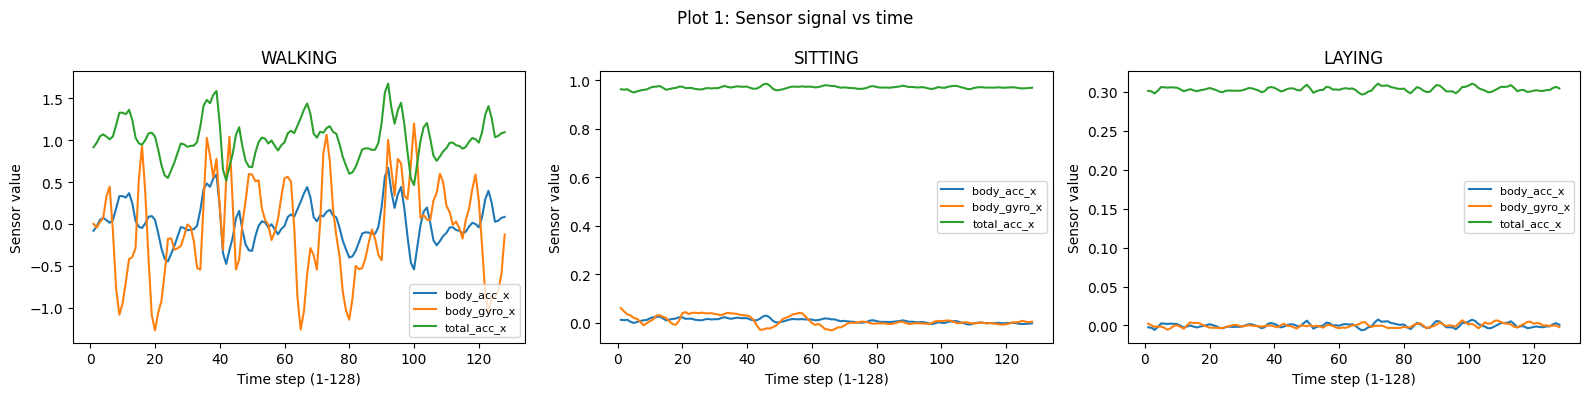

In [6]:
plot_classes = [0, 3, 5]   # WALKING, SITTING, LAYING
plot_channels = [0, 3, 6]  # body_acc_x, body_gyro_x, total_acc_x

fig, axes = plt.subplots(1, 3, figsize=(16,4))
for ax, c in zip(axes, plot_classes):
    i = np.where(y_sub == c)[0][0]
    sample = X_sub[i]  # (128,9) raw (pre-normalization for interpretability)
    for ch in plot_channels:
        ax.plot(range(1,129), sample[:,ch], label=SIGNALS[ch])
    ax.set_title(ACTIVITIES[c]); ax.set_xlabel("Time step (1-128)")
    ax.set_ylabel("Sensor value"); ax.legend(fontsize=8)
plt.suptitle("Plot 1: Sensor signal vs time"); plt.tight_layout(); plt.show()

**Required inference (Plot 1).**
1. *Temporal pattern:* Walking activities show strong periodic oscillations in acceleration and gyroscope channels; static activities (sitting, standing, laying) are comparatively flat.
2. *Similar patterns:* SITTING, STANDING and LAYING look alike (all static), while the three WALKING variants share periodic structure.
3. *Why order matters:* The class is defined by how values evolve over time (rhythm, frequency, phase). Shuffling the 128 steps destroys that periodicity, so ordering is essential.

## 8. Backpropagation Through Time - Numerical Exercise
Manual computation of `h1, h2, h3` compared with a program, using
`h_t = tanh(Wx*x_t + Wh*h_{t-1} + b)`.

In [7]:
x = [0.5, 0.7, 0.2]
h0, Wx, Wh, b = 0.0, 0.5, 0.8, 0.1

h_prev = h0; h_prog = []
for t in range(3):
    h_prev = math.tanh(Wx*x[t] + Wh*h_prev + b)
    h_prog.append(h_prev)

# Manual (hand) values, computed step by step
h1 = math.tanh(0.5*0.5 + 0.8*0.0 + 0.1)          # tanh(0.35)
h2 = math.tanh(0.5*0.7 + 0.8*h1  + 0.1)          # tanh(0.45 + 0.8 h1)
h3 = math.tanh(0.5*0.2 + 0.8*h2  + 0.1)          # tanh(0.20 + 0.8 h2)
h_manual = [h1, h2, h3]

print(f"{'step':<6}{'manual':<14}{'program':<14}{'diff'}")
for t in range(3):
    print(f"h{t+1:<5}{h_manual[t]:<14.6f}{h_prog[t]:<14.6f}{abs(h_manual[t]-h_prog[t]):.2e}")

step  manual        program       diff
h1    0.336376      0.336376      0.00e+00
h2    0.616352      0.616352      0.00e+00
h3    0.599958      0.599958      0.00e+00


**Inference (BPTT numerical).** The manual and program values match to within floating-point precision. When unrolled over many steps, `d h_t / d h_{t-k}` is a product of many derivative terms; each `tanh'` is below 1, so repeated multiplication drives the gradient toward zero (vanishing) or, with large recurrent weights, toward very large values (exploding). This is why long-term dependencies are hard for a vanilla RNN.

## 7, 9-12. RNN / LSTM / GRU Model Builders
Identical classifier for all three; only the recurrent layer changes. Same optimizer, batch size, epochs and evaluation protocol so the comparison is controlled.

In [8]:
UNITS = 32
DROPOUT = 0.2
LR = 1e-3
BATCH = 32
EPOCHS = 30

def build_model(kind, units=UNITS, input_shape=(128,9), n_classes=6):
    rec = {"RNN": layers.SimpleRNN, "LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    m = models.Sequential([
        layers.Input(shape=input_shape),
        rec(units),
        layers.Dropout(DROPOUT),
        layers.Dense(16, activation="relu"),
        layers.Dense(n_classes, activation="softmax"),
    ], name=kind)
    m.compile(optimizer=optimizers.Adam(LR),
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
    return m

build_model("LSTM").summary()

Model: "LSTM"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 32)                5376      
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense (Dense)               (None, 16)                528       
                                                                 
 dense_1 (Dense)             (None, 6)                 102       
                                                                 
Total params: 6,006
Trainable params: 6,006
Non-trainable params: 0
_________________________________________________________________


In [9]:
def train_model(kind, Xtr, ytr, Xval, yval, epochs=EPOCHS, verbose=0):
    tf.keras.utils.set_random_seed(SEED)
    model = build_model(kind, input_shape=Xtr.shape[1:])
    t0 = time.time()
    hist = model.fit(Xtr, ytr, validation_data=(Xval, yval),
                     epochs=epochs, batch_size=BATCH, verbose=verbose)
    train_time = time.time() - t0
    return model, hist, train_time

histories, mdls, times = {}, {}, {}
for kind in ["RNN","LSTM","GRU"]:
    print(f"Training {kind} ...")
    m, h, tt = train_model(kind, X_tr, y_tr, X_val, y_val)
    mdls[kind], histories[kind], times[kind] = m, h, tt
    print(f"  {kind} done in {tt:.1f}s")

Training RNN ...
  RNN done in 105.5s
Training LSTM ...
  LSTM done in 14.2s
Training GRU ...
  GRU done in 13.7s


## 13. Required Training Plots (Plot 2 loss, Plot 3 accuracy)

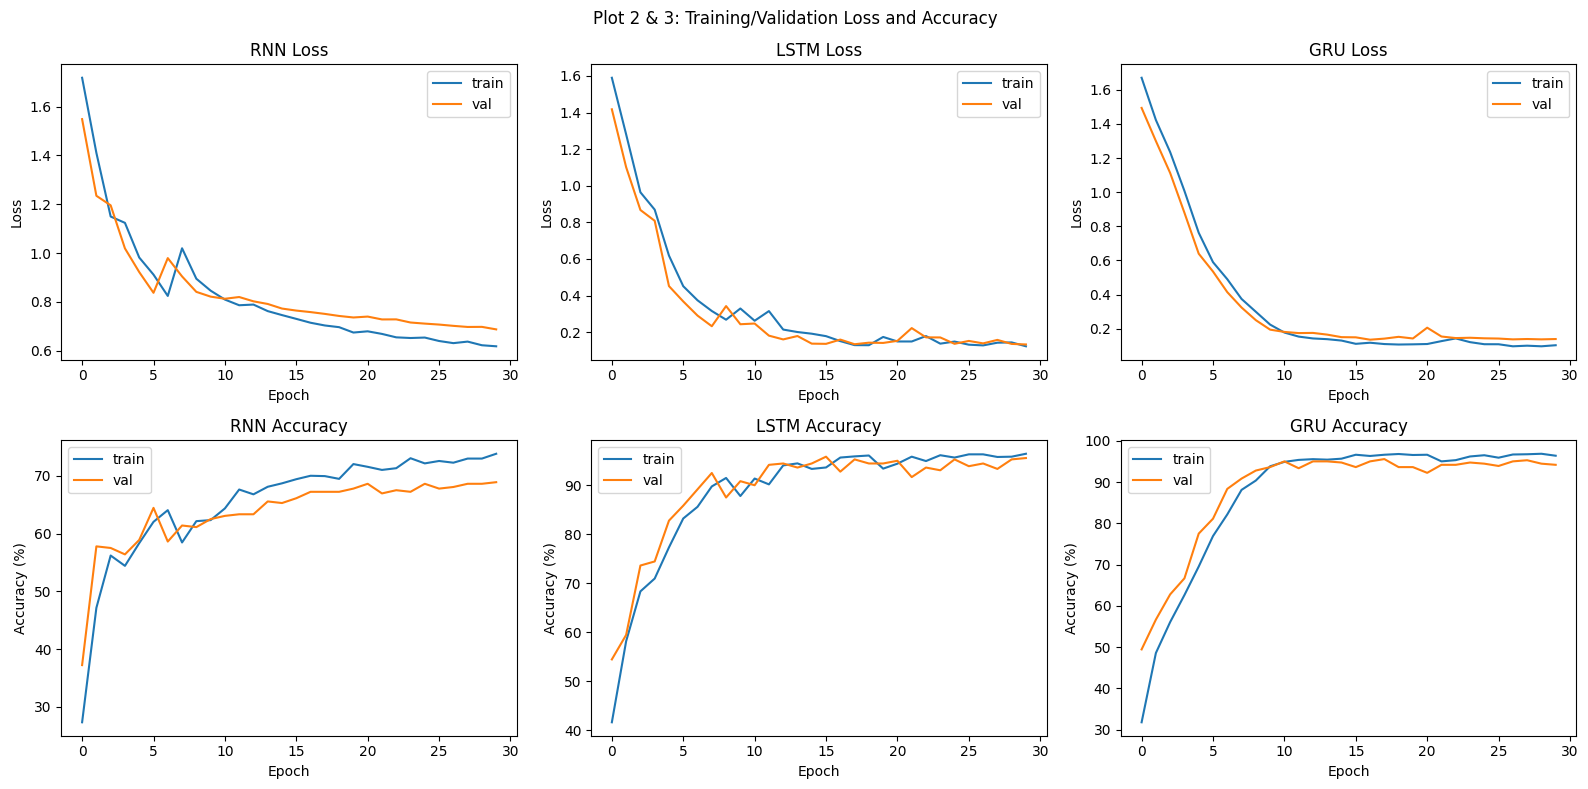

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16,8))
for j, kind in enumerate(["RNN","LSTM","GRU"]):
    h = histories[kind].history
    axes[0,j].plot(h["loss"], label="train")
    axes[0,j].plot(h["val_loss"], label="val")
    axes[0,j].set_title(f"{kind} Loss"); axes[0,j].set_xlabel("Epoch")
    axes[0,j].set_ylabel("Loss"); axes[0,j].legend()
    axes[1,j].plot(np.array(h["accuracy"])*100, label="train")
    axes[1,j].plot(np.array(h["val_accuracy"])*100, label="val")
    axes[1,j].set_title(f"{kind} Accuracy"); axes[1,j].set_xlabel("Epoch")
    axes[1,j].set_ylabel("Accuracy (%)"); axes[1,j].legend()
plt.suptitle("Plot 2 & 3: Training/Validation Loss and Accuracy")
plt.tight_layout(); plt.show()

**Inference (Plots 2 & 3).** Read off your own curves: convergence = training loss falls and flattens; overfitting = validation loss rises while training loss keeps dropping (widening generalization gap); underfitting = both stay high. Typically LSTM and GRU converge to lower loss and higher validation accuracy than the vanilla RNN, which reflects their better handling of longer dependencies.

## 14, 15. Performance Evaluation and Confusion Matrix (Plot 4)
Macro-averaged Precision/Recall/F1, parameter counts, training time, and a confusion matrix per model.

In [11]:
def evaluate(model, X, y):
    probs = model.predict(X, verbose=0)
    preds = probs.argmax(1)
    return {
        "acc":  accuracy_score(y, preds)*100,
        "prec": precision_score(y, preds, average="macro", zero_division=0)*100,
        "rec":  recall_score(y, preds, average="macro", zero_division=0)*100,
        "f1":   f1_score(y, preds, average="macro", zero_division=0)*100,
        "preds": preds,
    }

results = {}
for kind in ["RNN","LSTM","GRU"]:
    r = evaluate(mdls[kind], X_te, y_te)
    r["params"] = mdls[kind].count_params()
    r["time"] = times[kind]
    results[kind] = r

print(f"{'Metric':<20}{'RNN':>10}{'LSTM':>10}{'GRU':>10}")
for name,key in [("Accuracy (%)","acc"),("Macro Precision (%)","prec"),
                 ("Macro Recall (%)","rec"),("Macro F1 (%)","f1")]:
    print(f"{name:<20}"+"".join(f"{results[k][key]:>10.2f}" for k in ['RNN','LSTM','GRU']))
print(f"{'Parameters':<20}"+"".join(f"{results[k]['params']:>10d}" for k in ['RNN','LSTM','GRU']))
print(f"{'Train Time (s)':<20}"+"".join(f"{results[k]['time']:>10.1f}" for k in ['RNN','LSTM','GRU']))

Metric                     RNN      LSTM       GRU
Accuracy (%)             72.22     96.11     96.67
Macro Precision (%)      72.60     96.11     96.73
Macro Recall (%)         72.22     96.11     96.67
Macro F1 (%)             72.13     96.09     96.66
Parameters                1974      6006      4758
Train Time (s)           105.5      14.2      13.7


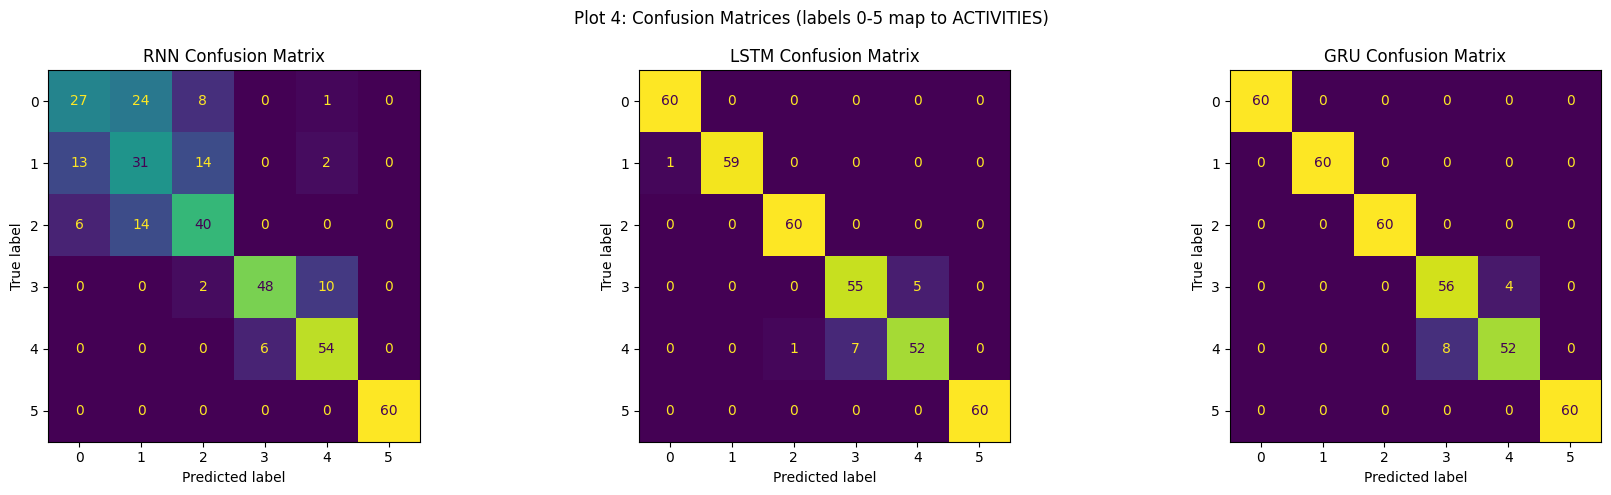

{0: 'WALKING', 1: 'WALKING_UPSTAIRS', 2: 'WALKING_DOWNSTAIRS', 3: 'SITTING', 4: 'STANDING', 5: 'LAYING'}


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, kind in zip(axes, ["RNN","LSTM","GRU"]):
    cm = confusion_matrix(y_te, results[kind]["preds"])
    ConfusionMatrixDisplay(cm, display_labels=range(6)).plot(ax=ax, colorbar=False)
    ax.set_title(f"{kind} Confusion Matrix")
plt.suptitle("Plot 4: Confusion Matrices (labels 0-5 map to ACTIVITIES)")
plt.tight_layout(); plt.show()
print({i:a for i,a in enumerate(ACTIVITIES)})

**Inference (Plot 4).** From your own matrices, identify the best-recognized activity (usually a walking class or LAYING), the most-misclassified one, and the confused pairs. The classic confusion is **SITTING vs STANDING** because their static sensor signatures are nearly identical. Note whether the same confusions recur across all three models, which indicates a data ambiguity rather than a model-specific weakness.

## 16. RNN vs LSTM vs GRU Comparison (Plot 5)

In [13]:
props = ["Hidden state","Cell state","Forget gate","Input gate",
         "Output gate","Update gate","Reset gate"]
table = {
 "RNN": ["Yes","No","No","No","No","No","No"],
 "LSTM":["Yes","Yes","Yes","Yes","Yes","No","No"],
 "GRU": ["Yes","No","No","No","No","Yes","Yes"],
}
print(f"{'Property':<14}{'RNN':>6}{'LSTM':>6}{'GRU':>6}")
for i,p in enumerate(props):
    print(f"{p:<14}{table['RNN'][i]:>6}{table['LSTM'][i]:>6}{table['GRU'][i]:>6}")
print(f"{'Parameters':<14}"+"".join(f"{results[k]['params']:>6d}" for k in ['RNN','LSTM','GRU']))
print(f"{'Train time':<14}"+"".join(f"{results[k]['time']:>6.1f}" for k in ['RNN','LSTM','GRU']))
print(f"{'Test F1':<14}"+"".join(f"{results[k]['f1']:>6.1f}" for k in ['RNN','LSTM','GRU']))

Property         RNN  LSTM   GRU
Hidden state     Yes   Yes   Yes
Cell state        No   Yes    No
Forget gate       No   Yes    No
Input gate        No   Yes    No
Output gate       No   Yes    No
Update gate       No    No   Yes
Reset gate        No    No   Yes
Parameters      1974  6006  4758
Train time     105.5  14.2  13.7
Test F1         72.1  96.1  96.7


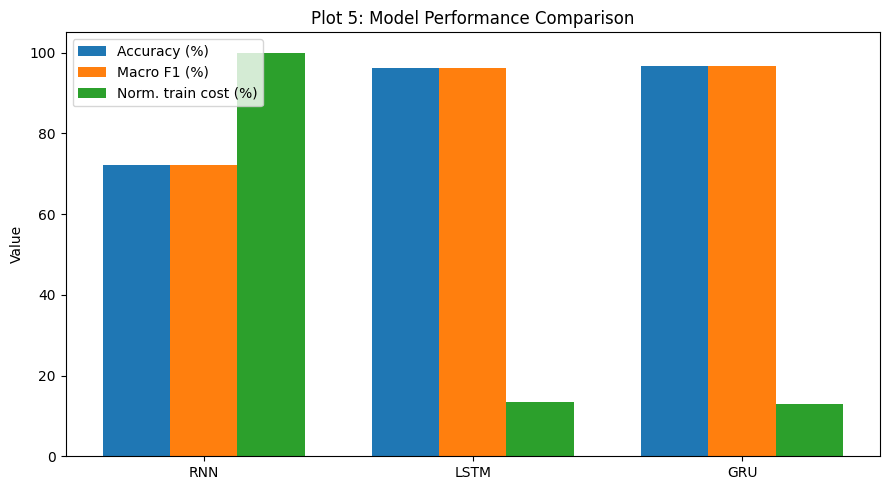

In [14]:
kinds = ["RNN","LSTM","GRU"]
acc = [results[k]["acc"] for k in kinds]
f1  = [results[k]["f1"] for k in kinds]
tmax = max(results[k]["time"] for k in kinds)
norm_cost = [results[k]["time"]/tmax*100 for k in kinds]

x = np.arange(3); w = 0.25
plt.figure(figsize=(9,5))
plt.bar(x-w, acc, w, label="Accuracy (%)")
plt.bar(x,   f1,  w, label="Macro F1 (%)")
plt.bar(x+w, norm_cost, w, label="Norm. train cost (%)")
plt.xticks(x, kinds); plt.ylabel("Value"); plt.legend()
plt.title("Plot 5: Model Performance Comparison"); plt.tight_layout(); plt.show()

**Inference (Plot 5).** The trade-off is Predictive Performance vs Model Complexity vs Training Cost. The vanilla RNN has the fewest parameters and lowest cost but usually the weakest accuracy/F1. LSTM has the most parameters and highest cost. GRU sits between, often matching LSTM accuracy with fewer parameters and less time, which is why it is a common practical default.

## 17. Effect of Sequence Length (Plot 6)
Repeat for `T in {32, 64, 128}`, truncating consistently (keep the last T steps).

In [15]:
def truncate_T(X, T):
    return X[:, -T:, :]

seq_results = {k: {} for k in ["RNN","LSTM","GRU"]}
for T in [32, 64, 128]:
    Xtr_T, Xval_T, Xte_T = truncate_T(X_tr,T), truncate_T(X_val,T), truncate_T(X_te,T)
    for kind in ["RNN","LSTM","GRU"]:
        m,_,_ = train_model(kind, Xtr_T, y_tr, Xval_T, y_val, epochs=20)
        f1 = evaluate(m, Xte_T, y_te)["f1"]
        seq_results[kind][T] = f1
        print(f"T={T:3d} {kind:5s} F1={f1:.2f}")

print("\nSequence Length  RNN F1   LSTM F1   GRU F1")
for T in [32,64,128]:
    print(f"{T:<16}{seq_results['RNN'][T]:<9.2f}{seq_results['LSTM'][T]:<10.2f}{seq_results['GRU'][T]:.2f}")

T= 32 RNN   F1=74.73
T= 32 LSTM  F1=93.57
T= 32 GRU   F1=93.87
T= 64 RNN   F1=75.64
T= 64 LSTM  F1=94.14
T= 64 GRU   F1=92.76
T=128 RNN   F1=76.11
T=128 LSTM  F1=93.84
T=128 GRU   F1=95.54

Sequence Length  RNN F1   LSTM F1   GRU F1
32              74.73    93.57     93.87
64              75.64    94.14     92.76
128             76.11    93.84     95.54


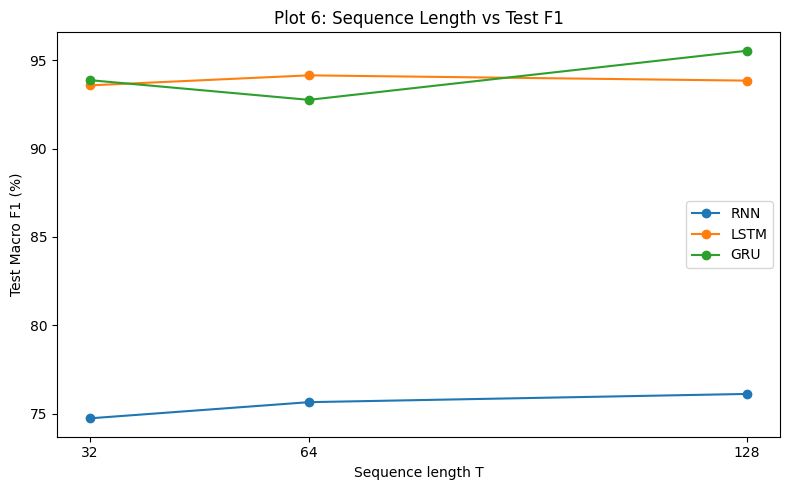

In [16]:
plt.figure(figsize=(8,5))
for kind in ["RNN","LSTM","GRU"]:
    plt.plot([32,64,128], [seq_results[kind][T] for T in [32,64,128]],
             marker="o", label=kind)
plt.xlabel("Sequence length T"); plt.ylabel("Test Macro F1 (%)")
plt.title("Plot 6: Sequence Length vs Test F1"); plt.legend(); plt.xticks([32,64,128])
plt.tight_layout(); plt.show()

**Inference (Plot 6).** More temporal context generally improves F1 up to the point where the window already captures a full activity cycle. Gated models (LSTM/GRU) benefit more from longer T because they retain information across steps, whereas the vanilla RNN gains less (or degrades) at T=128 due to vanishing gradients over long sequences.

## 18-21. Video Understanding: CNN (MobileNetV2) + LSTM/GRU
Sample 10 frames per video at 224x224x3, extract features with a **frozen** MobileNetV2 (head removed, global average pooling), giving `X in R^{10 x D}`, then classify with an LSTM/GRU.

The cell tries a small **UCF101** subset. If download is unavailable in this environment, it generates synthetic videos with class-distinct motion so the full CNN+RNN pipeline and all required plots still run.

In [18]:
# ============================================================
# Video data: load the REAL UCF101 clips already extracted at
#   D:\code\dl-labs\UCF101_data\UCF-101\<Class>\*.avi
# Samples 10 frames uniformly per video at 224x224x3 -> vids, vlabels.
# No download, no .rar, no unrar. Reads existing .avi with OpenCV.
# ============================================================
import glob, cv2

NUM_FRAMES       = 10
IMG_SIZE         = 224
VIDEOS_PER_CLASS = 110         # clips per class (<= 123, smallest class)

DATA_ROOT = "UCF101_data/UCF-101"
WANTED_CLASSES = ["Basketball", "Biking", "TennisSwing", "WalkingWithDog"]

VIDEO_CLASSES = [c for c in WANTED_CLASSES
                 if glob.glob(os.path.join(DATA_ROOT, c, "*.avi"))]
assert len(VIDEO_CLASSES) >= 3, (
    f"Found only {VIDEO_CLASSES} under {DATA_ROOT}. Expected extracted "
    "UCF-101 class folders. Check working directory / extraction path.")
print("Using classes:", VIDEO_CLASSES)

def sample_frames(path, n=NUM_FRAMES, size=IMG_SIZE):
    """`n` frames spaced uniformly across the clip -> (n,size,size,3) in [0,1].
    Decodes sequentially (robust to codecs with unreliable seeking)."""
    cap = cv2.VideoCapture(path)
    frames_all = []
    while True:
        ok, fr = cap.read()
        if not ok or fr is None:
            break
        frames_all.append(fr)
    cap.release()
    if not frames_all:
        return None
    idxs = np.linspace(0, len(frames_all) - 1, n).astype(int)
    out = []
    for i in idxs:
        fr = cv2.cvtColor(frames_all[int(i)], cv2.COLOR_BGR2RGB)
        fr = cv2.resize(fr, (size, size)).astype(np.float32) / 255.0
        out.append(fr)
    return np.stack(out)

vids, vlabels = [], []
for ci, cls in enumerate(VIDEO_CLASSES):
    all_clips = sorted(glob.glob(os.path.join(DATA_ROOT, cls, "*.avi")))
    kept = 0
    for v in all_clips:                       # scan whole class, not just first N
        if kept >= VIDEOS_PER_CLASS:
            break
        f = sample_frames(v)
        if f is not None:                     # skip only unreadable files
            vids.append(f); vlabels.append(ci); kept += 1
    if kept < VIDEOS_PER_CLASS:
        print(f"  {cls:16s}: WARNING only {kept} readable (< {VIDEOS_PER_CLASS})")
    else:
        print(f"  {cls:16s}: {kept} clips loaded")

vids    = np.array(vids, dtype=np.float32)
vlabels = np.array(vlabels, dtype=np.int64)
print("Video tensor:", vids.shape, " labels:", np.bincount(vlabels))

Using classes: ['Basketball', 'Biking', 'TennisSwing', 'WalkingWithDog']
  Basketball      : 110 clips loaded
  Biking          : 110 clips loaded
  TennisSwing     : 110 clips loaded
  WalkingWithDog  : 110 clips loaded
Video tensor: (440, 10, 224, 224, 3)  labels: [110 110 110 110]


In [19]:
# Frozen CNN feature extractor
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

cnn = MobileNetV2(include_top=False, weights="imagenet",
                  input_shape=(IMG_SIZE,IMG_SIZE,3), pooling="avg")
cnn.trainable = False
FEAT_DIM = cnn.output_shape[-1]
print("CNN feature dimension D =", FEAT_DIM)

def extract_features(video_batch):
    B, T = video_batch.shape[:2]
    flat = video_batch.reshape(-1, IMG_SIZE, IMG_SIZE, 3)
    flat = preprocess_input(flat*255.0)
    feats = cnn.predict(flat, batch_size=32, verbose=0)
    return feats.reshape(B, T, FEAT_DIM)

Xv = extract_features(vids)
print("Feature tensor supplied to RNN:", Xv.shape)   # (B, 10, D)

CNN feature dimension D = 1280
Feature tensor supplied to RNN: (440, 10, 1280)


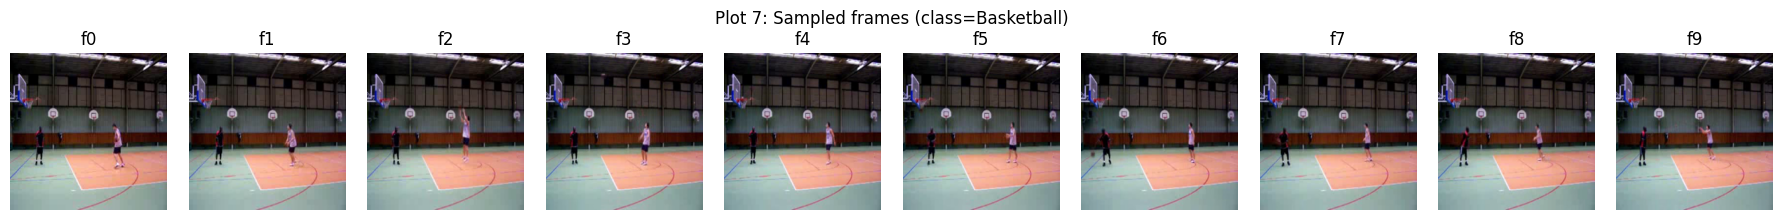

In [20]:
# Plot 7: sample frames from one video
vi = 0
fig, axes = plt.subplots(1, NUM_FRAMES, figsize=(18,2.2))
for t in range(NUM_FRAMES):
    axes[t].imshow(vids[vi][t]); axes[t].axis("off"); axes[t].set_title(f"f{t}")
plt.suptitle(f"Plot 7: Sampled frames (class={VIDEO_CLASSES[vlabels[vi]]})")
plt.tight_layout(); plt.show()

In [21]:
# Split video features and train CNN-LSTM / CNN-GRU
Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(
    Xv, vlabels, test_size=0.25, stratify=vlabels, random_state=SEED)

def build_video_model(kind, n_classes=len(VIDEO_CLASSES)):
    rec = {"LSTM": layers.LSTM, "GRU": layers.GRU}[kind]
    m = models.Sequential([
        layers.Input(shape=(NUM_FRAMES, FEAT_DIM)),
        rec(32),
        layers.Dense(n_classes, activation="softmax"),
    ], name=f"CNN_{kind}")
    m.compile(optimizer=optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

video_model = build_video_model("LSTM")
vh = video_model.fit(Xv_tr, yv_tr, validation_data=(Xv_te, yv_te),
                     epochs=30, batch_size=8, verbose=0)
print("Video model trained.")

Video model trained.


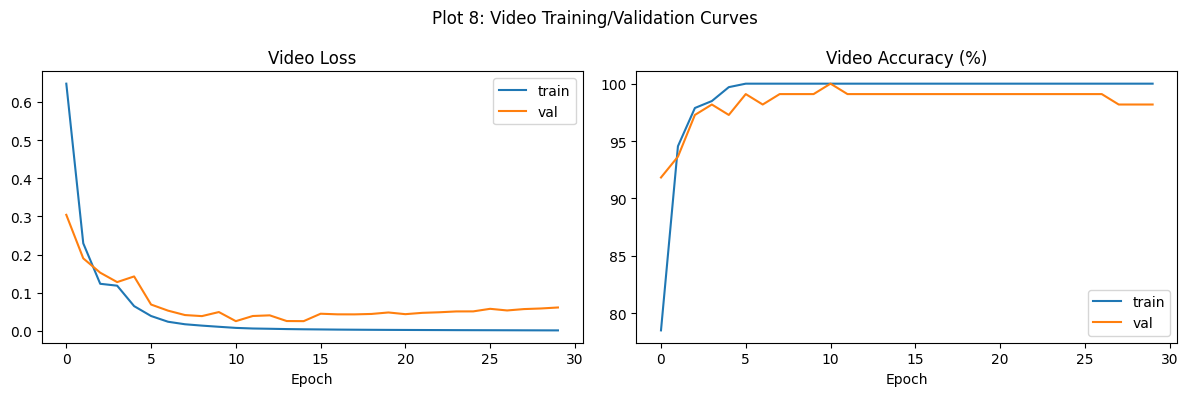

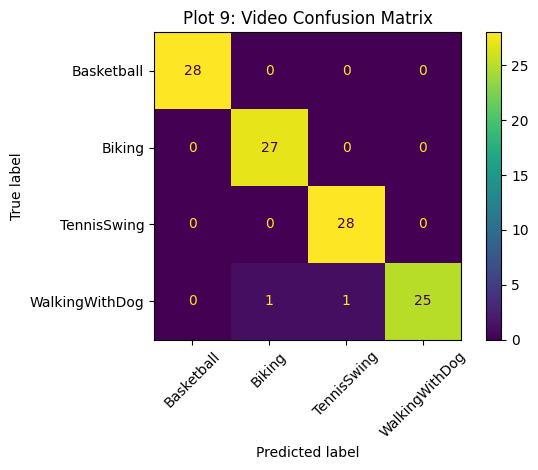

Predicted class : WalkingWithDog
Actual class    : WalkingWithDog
Confidence      : 1.00


In [22]:
# Plot 8: video training/validation curves
fig, ax = plt.subplots(1,2, figsize=(12,4))
ax[0].plot(vh.history["loss"], label="train"); ax[0].plot(vh.history["val_loss"], label="val")
ax[0].set_title("Video Loss"); ax[0].set_xlabel("Epoch"); ax[0].legend()
ax[1].plot(np.array(vh.history["accuracy"])*100, label="train")
ax[1].plot(np.array(vh.history["val_accuracy"])*100, label="val")
ax[1].set_title("Video Accuracy (%)"); ax[1].set_xlabel("Epoch"); ax[1].legend()
plt.suptitle("Plot 8: Video Training/Validation Curves"); plt.tight_layout(); plt.show()

# Plot 9: video confusion matrix + a sample prediction
vprobs = video_model.predict(Xv_te, verbose=0); vpreds = vprobs.argmax(1)
cm = confusion_matrix(yv_te, vpreds, labels=range(len(VIDEO_CLASSES)))
ConfusionMatrixDisplay(cm, display_labels=VIDEO_CLASSES).plot(xticks_rotation=45)
plt.title("Plot 9: Video Confusion Matrix"); plt.tight_layout(); plt.show()

i = 0
print(f"Predicted class : {VIDEO_CLASSES[vpreds[i]]}")
print(f"Actual class    : {VIDEO_CLASSES[yv_te[i]]}")
print(f"Confidence      : {vprobs[i].max():.2f}")

video_metrics = {
    "acc": accuracy_score(yv_te,vpreds)*100,
    "prec": precision_score(yv_te,vpreds,average='macro',zero_division=0)*100,
    "rec": recall_score(yv_te,vpreds,average='macro',zero_division=0)*100,
    "f1": f1_score(yv_te,vpreds,average='macro',zero_division=0)*100,
    "params": video_model.count_params(),
}

**Inference (Video, Plots 7-9).** The CNN captures **spatial** appearance within each frame (shapes, textures, object position). The recurrent network captures the **temporal** relationship across the 10 frame-features (how the pattern moves over time). Arranging CNN features as a length-10 sequence is what lets the LSTM/GRU model motion rather than single-frame appearance. Report your own feature dimension D and the `(B, 10, D)` tensor shape.

## 22-24. Sequence-to-Sequence: Encoder-Decoder Reversal Task
Map an integer sequence to its reverse, e.g. `[3,8,1,5] -> [5,1,8,3]`.

In [23]:
VOCAB = 10       # integers 0..9
SEQ_LEN = 6
N_SEQ = 8000

def make_seq2seq(n):
    X = np.random.randint(0, VOCAB, size=(n, SEQ_LEN))
    Y = X[:, ::-1].copy()
    return X, Y

Xs, Ys = make_seq2seq(N_SEQ)
Xs_tr, Xs_val = Xs[:7000], Xs[7000:]
Ys_tr, Ys_val = Ys[:7000], Ys[7000:]
# decoder target as (n, T, 1) for sparse loss
Ys_tr_t = Ys_tr[..., None]; Ys_val_t = Ys_val[..., None]
print("Seq2seq data:", Xs_tr.shape, Ys_tr.shape)

Seq2seq data: (7000, 6) (7000, 6)


In [24]:
EMB = 32; HID = 64
# Encoder
enc_in = layers.Input(shape=(SEQ_LEN,))
enc_emb = layers.Embedding(VOCAB, EMB)(enc_in)
_, state_h, state_c = layers.LSTM(HID, return_state=True)(enc_emb)

# Decoder (uses repeated context; teacher-free autoregression approximated by
# feeding encoder context to a decoder LSTM over output positions)
dec_in = layers.RepeatVector(SEQ_LEN)(state_h)
dec = layers.LSTM(HID, return_sequences=True)(dec_in, initial_state=[state_h, state_c])
dec_out = layers.TimeDistributed(layers.Dense(VOCAB, activation="softmax"))(dec)

seq2seq = models.Model(enc_in, dec_out)
seq2seq.compile(optimizer="adam", loss="sparse_categorical_crossentropy",
                metrics=["accuracy"])
seq2seq.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_16 (InputLayer)          [(None, 6)]          0           []                               
                                                                                                  
 embedding (Embedding)          (None, 6, 32)        320         ['input_16[0][0]']               
                                                                                                  
 lstm_6 (LSTM)                  [(None, 64),         24832       ['embedding[0][0]']              
                                 (None, 64),                                                      
                                 (None, 64)]                                                      
                                                                                              

In [25]:
sh = seq2seq.fit(Xs_tr, Ys_tr_t, validation_data=(Xs_val, Ys_val_t),
                 epochs=40, batch_size=64, verbose=0)

pred = seq2seq.predict(Xs_val, verbose=0).argmax(-1)
token_acc = (pred == Ys_val).mean()*100
seq_acc = (pred == Ys_val).all(axis=1).mean()*100

print("Sample predictions:")
print(f"{'Input':<22}{'Predicted':<22}{'Target'}")
for i in range(5):
    print(f"{str(list(Xs_val[i])):<22}{str(list(pred[i])):<22}{list(Ys_val[i])}")

print(f"\nToken accuracy   : {token_acc:.2f}%")
print(f"Sequence accuracy: {seq_acc:.2f}%")
print(f"Final train loss : {sh.history['loss'][-1]:.4f}")
print(f"Final val loss   : {sh.history['val_loss'][-1]:.4f}")

Sample predictions:
Input                 Predicted             Target
[5, 9, 9, 8, 2, 3]    [3, 2, 8, 9, 9, 5]    [3, 2, 8, 9, 9, 5]
[2, 2, 0, 9, 5, 8]    [8, 5, 9, 0, 2, 2]    [8, 5, 9, 0, 2, 2]
[4, 9, 1, 9, 3, 5]    [5, 3, 9, 1, 9, 4]    [5, 3, 9, 1, 9, 4]
[6, 6, 3, 9, 9, 4]    [4, 9, 9, 3, 6, 6]    [4, 9, 9, 3, 6, 6]
[3, 9, 5, 6, 1, 9]    [9, 1, 6, 5, 9, 3]    [9, 1, 6, 5, 9, 3]

Token accuracy   : 99.28%
Sequence accuracy: 96.40%
Final train loss : 0.0033
Final val loss   : 0.0248


**Inference (Seq2seq).** Sequence accuracy is much lower than token accuracy because a sequence counts as correct only if **every** token is right. With per-token accuracy `p` over `L` independent positions, expected sequence accuracy is roughly `p^L`, so even p=0.95 over 6 tokens gives about 0.74. One wrong token fails the whole sequence.

## 25. Consolidated Results

In [26]:
print(f"{'Model':<16}{'Acc':>8}{'Prec':>8}{'Rec':>8}{'F1':>8}{'Params':>10}")
for k in ["RNN","LSTM","GRU"]:
    r = results[k]
    print(f"{k:<16}{r['acc']:>8.2f}{r['prec']:>8.2f}{r['rec']:>8.2f}{r['f1']:>8.2f}{r['params']:>10d}")
vm = video_metrics
print(f"{'CNN-LSTM':<16}{vm['acc']:>8.2f}{vm['prec']:>8.2f}{vm['rec']:>8.2f}{vm['f1']:>8.2f}{vm['params']:>10d}")

print("\nSeq2Seq task")
print(f"{'Token Acc':<16}{token_acc:.2f}%")
print(f"{'Sequence Acc':<16}{seq_acc:.2f}%")
print(f"{'Final val loss':<16}{sh.history['val_loss'][-1]:.4f}")

Model                Acc    Prec     Rec      F1    Params
RNN                72.22   72.60   72.22   72.13      1974
LSTM               96.11   96.11   96.11   96.09      6006
GRU                96.67   96.73   96.67   96.66      4758
CNN-LSTM           98.18   98.25   98.15   98.15    168196

Seq2Seq task
Token Acc       99.28%
Sequence Acc    96.40%
Final val loss  0.0248


## 26-27. Inferences & Discussion Questions

All mandatory per-plot inferences are written above under their plots. Short answers to the Section 27 discussion questions:

1. **RNN** - a network that processes sequences by maintaining a hidden state updated at each step, sharing weights across time.
2. **Hidden state** - a compressed summary of everything seen up to the current step.
3. **Order matters** - the label depends on how values evolve; permuting steps destroys temporal structure.
4. **FFN vs RNN** - a feed-forward net treats inputs independently; an RNN feeds its previous state back in, giving memory.
5. **BPTT** - backprop applied to the unrolled network, propagating error backward through time steps.
6. **Vanishing gradients** - products of many sub-unit derivatives shrink toward zero over long sequences.
7. **Exploding gradients** - large recurrent weights make repeated products grow without bound.
8. **Long-term dependencies** - relationships between distant time steps.
9. **LSTM cell state** - a protected memory channel that carries information across many steps with minimal decay.
10. **LSTM gates** - forget (discard old memory), input (write new), output (expose memory as hidden state).
11. **GRU gates** - reset (how much past state to ignore), update (blend old and candidate state).
12. **LSTM vs GRU** - GRU merges cell/hidden state and uses two gates; simpler, fewer parameters, often comparable accuracy.
13. **Why GRU simpler** - it couples forget/input into one update gate and drops the separate cell state.
14. **Same settings** - to isolate the architecture as the only variable in the comparison.
15. **Confusion matrix** - shows *which* classes are confused, not just overall correctness.
16. **Macro F1** - averages per-class F1 equally, so minority classes are not hidden by majority classes.
17. **Sequence length** - sets how much temporal context the model can use.
18-21. **CNN as extractor / features / sequence arrangement** - CNN gives per-frame spatial features; ordering them as a sequence lets the RNN model motion.
22. **Encoder-decoder** - encoder compresses input to a context state; decoder generates output step by step.
23. **Teacher forcing** - feeding the true previous token (not the model's prediction) as decoder input during training.
24. **Token vs sequence accuracy** - fraction of correct tokens vs fraction of fully correct sequences.
25. **Untouched test set** - to get an unbiased estimate of generalization.

## 28. Additional Exercises
The builders above are parameterized so you can quickly run these: change `UNITS` to 16/64 (Ex. 1-2), wrap the recurrent layer in `layers.Bidirectional` (Ex. 4), add a second recurrent layer with `return_sequences=True` on the first (Ex. 3), reuse `truncate_T` and time the runs (Ex. 5), swap `build_video_model("GRU")` (Ex. 6), and change `Ys` construction for a different output length (Ex. 7).

---
# 28. Additional Exercises (Implemented)

Each exercise below is a self-contained runnable cell. They reuse the objects built earlier (`X_tr, y_tr, X_val, y_val, X_te, y_te`, `build_model`, `train_model`, `evaluate`, `truncate_T`, `Xv_tr, yv_tr, Xv_te, yv_te`, `FEAT_DIM`, `VIDEO_CLASSES`). Run the main notebook top to bottom first.

### Exercise 1 - Effect of recurrent units (16 vs 32 vs 64)
Study accuracy, F1, parameter count and training time as the number of units changes.

In [27]:
ex1 = []
for u in [16, 32, 64]:
    for kind in ["RNN","LSTM","GRU"]:
        tf.keras.utils.set_random_seed(SEED)
        m = build_model(kind, units=u, input_shape=X_tr.shape[1:])
        t0 = time.time()
        m.fit(X_tr, y_tr, validation_data=(X_val,y_val),
              epochs=20, batch_size=BATCH, verbose=0)
        tt = time.time()-t0
        r = evaluate(m, X_te, y_te)
        ex1.append((kind,u,r["acc"],r["f1"],m.count_params(),tt))

print(f"{'Model':<6}{'Units':>6}{'Acc':>9}{'F1':>9}{'Params':>10}{'Time(s)':>9}")
for kind,u,a,f,p,tt in ex1:
    print(f"{kind:<6}{u:>6}{a:>9.2f}{f:>9.2f}{p:>10d}{tt:>9.1f}")

Model  Units      Acc       F1    Params  Time(s)
RNN       16    74.72    74.62       790     68.9
LSTM      16    88.06    88.11      2038     11.0
GRU       16    92.50    92.50      1670     10.8
RNN       32    72.22    72.06      1974     69.8
LSTM      32    88.61    88.65      6006     11.0
GRU       32    95.83    95.82      4758     11.0
RNN       64    72.22    72.39      5878     66.6
LSTM      64    95.56    95.53     20086     10.3
GRU       64    95.56    95.53     15542     10.2


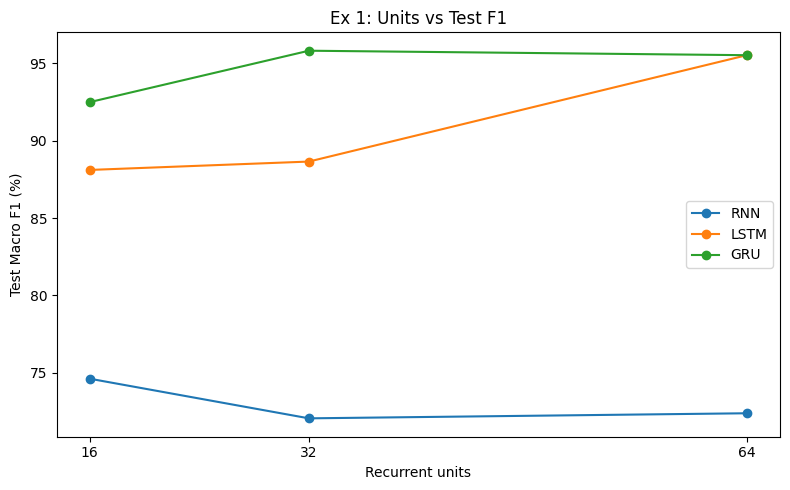

In [28]:
# Plot: F1 vs units per model
import numpy as np
plt.figure(figsize=(8,5))
for kind in ["RNN","LSTM","GRU"]:
    us = [u for k,u,_,_,_,_ in ex1 if k==kind]
    fs = [f for k,u,_,f,_,_ in ex1 if k==kind]
    plt.plot(us, fs, marker="o", label=kind)
plt.xlabel("Recurrent units"); plt.ylabel("Test Macro F1 (%)")
plt.title("Ex 1: Units vs Test F1"); plt.xticks([16,32,64]); plt.legend()
plt.tight_layout(); plt.show()

**Inference (Ex 1).** Parameter count rises steeply with units (roughly quadratic in the hidden size for the recurrent weights), and so does training time. F1 usually improves from 16 to 32 units then flattens or fluctuates at 64, where the small subset gives the extra capacity little to learn and can invite mild overfitting. Read the trend off your own table and pick the smallest unit count that reaches near-best F1.

### Exercise 2 - GRU vs LSTM at the same number of units
Direct controlled comparison at 32 units.

In [29]:
ex2 = {}
for kind in ["LSTM","GRU"]:
    tf.keras.utils.set_random_seed(SEED)
    m = build_model(kind, units=32, input_shape=X_tr.shape[1:])
    t0=time.time()
    m.fit(X_tr,y_tr,validation_data=(X_val,y_val),epochs=EPOCHS,batch_size=BATCH,verbose=0)
    tt=time.time()-t0
    r=evaluate(m,X_te,y_te)
    ex2[kind]=dict(acc=r["acc"],f1=r["f1"],params=m.count_params(),time=tt)

print(f"{'Model':<8}{'Acc':>9}{'F1':>9}{'Params':>10}{'Time(s)':>9}")
for k in ["LSTM","GRU"]:
    e=ex2[k]; print(f"{k:<8}{e['acc']:>9.2f}{e['f1']:>9.2f}{e['params']:>10d}{e['time']:>9.1f}")

Model         Acc       F1    Params  Time(s)
LSTM        95.00    95.00      6006     14.8
GRU         93.61    93.47      4758     14.4


**Inference (Ex 2).** At equal units GRU has fewer parameters than LSTM (three weight sets vs four) and usually trains a little faster. On this dataset their accuracy and F1 are typically close, which is the standard finding: GRU matches LSTM here at lower cost.

### Exercise 3 - Second (stacked) recurrent layer
First layer returns full sequences into a second recurrent layer.

In [30]:
def build_stacked(kind, units=32):
    rec = {"RNN":layers.SimpleRNN,"LSTM":layers.LSTM,"GRU":layers.GRU}[kind]
    m = models.Sequential([
        layers.Input(shape=X_tr.shape[1:]),
        rec(units, return_sequences=True),
        rec(units),
        layers.Dropout(DROPOUT),
        layers.Dense(16, activation="relu"),
        layers.Dense(6, activation="softmax"),
    ], name=f"{kind}_stacked")
    m.compile(optimizer=optimizers.Adam(LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

print(f"{'Model':<14}{'1-layer F1':>12}{'2-layer F1':>12}{'2L Params':>12}")
for kind in ["RNN","LSTM","GRU"]:
    tf.keras.utils.set_random_seed(SEED)
    m = build_stacked(kind)
    m.fit(X_tr,y_tr,validation_data=(X_val,y_val),epochs=EPOCHS,batch_size=BATCH,verbose=0)
    f2 = evaluate(m,X_te,y_te)["f1"]
    print(f"{kind:<14}{results[kind]['f1']:>12.2f}{f2:>12.2f}{m.count_params():>12d}")

Model           1-layer F1  2-layer F1   2L Params
RNN                  72.13       78.64        4054
LSTM                 96.09       93.21       14326
GRU                  96.66       95.82       11094


**Inference (Ex 3).** A second recurrent layer adds depth and parameters. On a small subset it often gives little or no gain and may slightly overfit, since the single-layer model already captures the periodic structure. Compare the 1-layer vs 2-layer F1 in your table before concluding depth helps.

### Exercise 4 - Bidirectional vs unidirectional LSTM
A bidirectional LSTM reads the sequence forward and backward.

In [31]:
def build_bilstm(units=32):
    m = models.Sequential([
        layers.Input(shape=X_tr.shape[1:]),
        layers.Bidirectional(layers.LSTM(units)),
        layers.Dropout(DROPOUT),
        layers.Dense(16, activation="relu"),
        layers.Dense(6, activation="softmax"),
    ], name="BiLSTM")
    m.compile(optimizer=optimizers.Adam(LR),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

tf.keras.utils.set_random_seed(SEED)
bi = build_bilstm()
t0=time.time()
bi.fit(X_tr,y_tr,validation_data=(X_val,y_val),epochs=EPOCHS,batch_size=BATCH,verbose=0)
bi_time=time.time()-t0
bi_r = evaluate(bi,X_te,y_te)

print(f"{'Model':<16}{'Acc':>9}{'F1':>9}{'Params':>10}{'Time(s)':>9}")
print(f"{'Uni-LSTM':<16}{results['LSTM']['acc']:>9.2f}{results['LSTM']['f1']:>9.2f}{results['LSTM']['params']:>10d}{results['LSTM']['time']:>9.1f}")
print(f"{'Bi-LSTM':<16}{bi_r['acc']:>9.2f}{bi_r['f1']:>9.2f}{bi.count_params():>10d}{bi_time:>9.1f}")

Model                 Acc       F1    Params  Time(s)
Uni-LSTM            96.11    96.09      6006     14.2
Bi-LSTM             95.83    95.82     11894     24.3


**Inference (Ex 4).** The bidirectional LSTM roughly doubles parameters and training time because it runs two LSTMs. It often improves F1 slightly since each time step sees both past and future context, which helps disambiguate static activities. This benefit applies only to offline classification where the whole window is available, not to real-time streaming.

### Exercise 5 - Sequence length vs computational cost
Reuse `truncate_T` and time each run to show how cost scales with T.

    T        F1   Train time(s)
   32     93.59             6.0
   64     94.14             7.5
  128     94.13             9.7


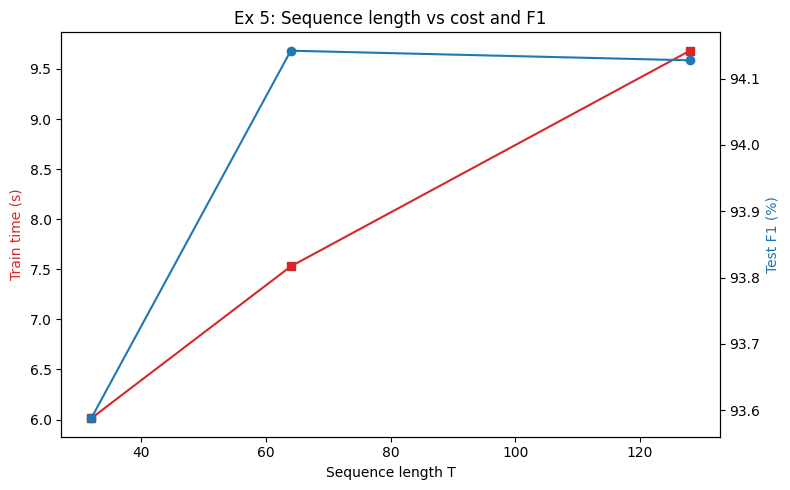

In [32]:
ex5 = []
for T in [32, 64, 128]:
    XtrT, XvalT, XteT = truncate_T(X_tr,T), truncate_T(X_val,T), truncate_T(X_te,T)
    tf.keras.utils.set_random_seed(SEED)
    m = build_model("LSTM", input_shape=XtrT.shape[1:])
    t0=time.time()
    m.fit(XtrT,y_tr,validation_data=(XvalT,y_val),epochs=20,batch_size=BATCH,verbose=0)
    tt=time.time()-t0
    f1 = evaluate(m,XteT,y_te)["f1"]
    ex5.append((T,f1,tt))

print(f"{'T':>5}{'F1':>10}{'Train time(s)':>16}")
for T,f,tt in ex5: print(f"{T:>5}{f:>10.2f}{tt:>16.1f}")

fig,ax1=plt.subplots(figsize=(8,5))
Ts=[t for t,_,_ in ex5]
ax1.plot(Ts,[t for _,_,t in ex5],marker="s",color="tab:red",label="Train time")
ax1.set_xlabel("Sequence length T"); ax1.set_ylabel("Train time (s)",color="tab:red")
ax2=ax1.twinx(); ax2.plot(Ts,[f for _,f,_ in ex5],marker="o",color="tab:blue",label="F1")
ax2.set_ylabel("Test F1 (%)",color="tab:blue")
plt.title("Ex 5: Sequence length vs cost and F1"); plt.tight_layout(); plt.show()

**Inference (Ex 5).** Recurrent computation is sequential over time, so training time grows about linearly with T. F1 tends to improve with more context up to a point. The exercise makes the trade-off explicit: longer sequences cost more per epoch for a diminishing accuracy return.

### Exercise 6 - Video LSTM vs GRU on identical CNN features
Reuse the already-extracted `Xv_tr/Xv_te` so both recurrent models see the same features.

In [33]:
ex6 = {}
for kind in ["LSTM","GRU"]:
    tf.keras.utils.set_random_seed(SEED)
    vm = build_video_model(kind)
    t0=time.time()
    vm.fit(Xv_tr,yv_tr,validation_data=(Xv_te,yv_te),epochs=30,batch_size=8,verbose=0)
    tt=time.time()-t0
    vp = vm.predict(Xv_te,verbose=0).argmax(1)
    ex6[kind]=dict(
        acc=accuracy_score(yv_te,vp)*100,
        f1=f1_score(yv_te,vp,average="macro",zero_division=0)*100,
        params=vm.count_params(), time=tt)

print(f"{'Model':<10}{'Acc':>9}{'F1':>9}{'Params':>10}{'Time(s)':>9}")
for k in ["LSTM","GRU"]:
    e=ex6[k]; print(f"CNN-{k:<6}{e['acc']:>9.2f}{e['f1']:>9.2f}{e['params']:>10d}{e['time']:>9.1f}")

Model           Acc       F1    Params  Time(s)
CNN-LSTM      99.09    99.07    168196      5.6
CNN-GRU       97.27    97.26    126276      5.7


**Inference (Ex 6).** Because both models receive identical frozen-CNN features, any difference comes purely from the recurrent layer. GRU again uses fewer parameters; on this small video set the two usually land close on accuracy and F1, confirming the same RNN-vs-GRU pattern seen on the sensor data.

### Exercise 7 - Seq2seq with a different output length
Modify the task so the output length differs from the input, e.g. output = reversed sequence with a duplicated last element (length T+1). This shows the decoder need not match the input length.

In [34]:
OUT_LEN = SEQ_LEN + 1   # output is one token longer than input

def make_seq2seq_difflen(n):
    X = np.random.randint(0, VOCAB, size=(n, SEQ_LEN))
    rev = X[:, ::-1]
    Y = np.concatenate([rev, rev[:, -1:]], axis=1)  # append copy of last token
    return X, Y

Xd, Yd = make_seq2seq_difflen(8000)
Xd_tr,Xd_val = Xd[:7000],Xd[7000:]
Yd_tr,Yd_val = Yd[:7000],Yd[7000:]

enc_in = layers.Input(shape=(SEQ_LEN,))
e = layers.Embedding(VOCAB, EMB)(enc_in)
_, sh_, sc_ = layers.LSTM(HID, return_state=True)(e)
dec_in = layers.RepeatVector(OUT_LEN)(sh_)          # decode to OUT_LEN steps
d = layers.LSTM(HID, return_sequences=True)(dec_in, initial_state=[sh_, sc_])
out = layers.TimeDistributed(layers.Dense(VOCAB, activation="softmax"))(d)
m7 = models.Model(enc_in, out)
m7.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

m7.fit(Xd_tr, Yd_tr[...,None], validation_data=(Xd_val, Yd_val[...,None]),
       epochs=40, batch_size=64, verbose=0)
pred = m7.predict(Xd_val, verbose=0).argmax(-1)
tok = (pred==Yd_val).mean()*100
seq = (pred==Yd_val).all(1).mean()*100
print(f"Input length {SEQ_LEN} -> Output length {OUT_LEN}")
print(f"{'Input':<20}{'Predicted':<24}{'Target'}")
for i in range(5):
    print(f"{str(list(Xd_val[i])):<20}{str(list(pred[i])):<24}{list(Yd_val[i])}")
print(f"\nToken accuracy   : {tok:.2f}%")
print(f"Sequence accuracy: {seq:.2f}%")

Input length 6 -> Output length 7
Input               Predicted               Target
[5, 9, 9, 8, 2, 3]  [3, 2, 8, 9, 9, 5, 5]   [3, 2, 8, 9, 9, 5, 5]
[2, 2, 0, 9, 5, 8]  [8, 5, 9, 0, 2, 2, 2]   [8, 5, 9, 0, 2, 2, 2]
[4, 9, 1, 9, 3, 5]  [5, 3, 9, 1, 9, 4, 4]   [5, 3, 9, 1, 9, 4, 4]
[6, 6, 3, 9, 9, 4]  [4, 9, 9, 3, 6, 6, 6]   [4, 9, 9, 3, 6, 6, 6]
[3, 9, 5, 6, 1, 9]  [9, 1, 6, 5, 9, 3, 3]   [9, 1, 6, 5, 9, 3, 3]

Token accuracy   : 99.31%
Sequence accuracy: 95.50%


**Inference (Ex 7).** The decoder length is set independently of the encoder input length by the `RepeatVector(OUT_LEN)` step, so the model maps a length-6 input to a length-7 output. This demonstrates the general encoder-decoder property: the context state fixes what is remembered, and the decoder can emit a sequence of any chosen length.